[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cca-cce/osm-comm/blob/main/jnb/komp014/02_methods.ipynb)

# 2. Methods

This study used a cross-sectional Theory of Planned Behavior (TPB) survey with
an embedded two-group, between-subjects experiment. Attitude (ATT), subjective
norm (SN), and perceived behavioral control (PBC) were measured before the
experimental manipulation; behavioral intention (BI) was measured afterward.
Each case was assigned to either a control condition or a peer-testimonial
treatment condition. The analysis below uses **1,000 synthetic records** created
for teaching. They are not observations from children and must not be presented
as empirical participant data.


## 2.1 Participants

The intended target population was children aged 10--13 years in Grades 4--6
who could consider beginning to learn a musical instrument. No children were
actually recruited or sampled for the synthetic dataset. The records reproduce
the composition of a possible school-based sample, but they do not constitute a
probability sample and cannot support population prevalence estimates. In a
field replication, a sampling frame of eligible schools and pupils should be
used, with stratification by grade and school followed by random selection of
schools or classes. This would make selection probabilities explicit while
keeping data collection feasible.

Table 1 describes the synthetic cases. Percentages use all 1,000 records as the
denominator because the file contains no missing demographic values.

| Characteristic | Category | *n* | % |
|---|---|---:|---:|
| Age group | 10 years | 258 | 25.8 |
|  | 11 years | 324 | 32.4 |
|  | 12 years | 322 | 32.2 |
|  | 13 years | 96 | 9.6 |
| Grade level | Grade 4 | 307 | 30.7 |
|  | Grade 5 | 352 | 35.2 |
|  | Grade 6 | 341 | 34.1 |
| Gender | Girl | 462 | 46.2 |
|  | Boy | 496 | 49.6 |
|  | Non-binary | 24 | 2.4 |
|  | Prefer not to say | 18 | 1.8 |

: Demographic profile of the synthetic cases. {#tbl-demographics}

Because the analyzed records are wholly synthetic, the present analysis did
not involve human participants or expose personal data. A real study involving
minors would nevertheless require prior ethics review where applicable,
age-appropriate child assent and parent or guardian permission, a clear account
of purpose and data use, voluntary participation and withdrawal without
penalty, and data minimization. Responses should be collected anonymously or
pseudonymously, stored securely, and reported only in aggregate. The control
and treatment materials should be age appropriate and non-coercive, and pupils
should be debriefed about random assignment after participation.


## 2.2 Measurement instrument

The instrument contained three demographic variables, 12 TPB items, and one
experimental assignment variable. Age group and grade level were ordered
categorical variables; gender was nominal; and experimental condition was a
binary nominal variable. Each TPB item was an ordered categorical item with the
same five response options: 1 = strongly disagree, 2 = disagree, 3 = neither
agree nor disagree, 4 = agree, and 5 = strongly agree. The three-item mean
indices were treated as approximately continuous in the planned analyses.

| Construct | Three indicators | Role in analysis |
|---|---|---|
| Attitude (ATT) | Learning an instrument would be fun and exciting; a valuable use of time; make me feel good about myself | Independent variable |
| Subjective norm (SN) | Parent or guardian approval; friend approval; teacher encouragement | Independent variable |
| Perceived behavioral control (PBC) | Confidence in ability to learn; enough spare time; access to an instrument | Independent variable |
| Behavioral intention (BI) | Plan to learn in the next six months; intend to try my best soon; want to start this school year | Dependent variable |

: Operationalization of the four TPB constructs. {#tbl-measures}

All TPB items were positively keyed, so none required reverse coding. Multiple
indicators were used because the theoretical constructs are not directly
observable and a mean index reduces dependence on any single response. Internal
consistency was checked before creating each index.

The planned survey flow was demographics and the three pre-treatment TPB
predictors, random assignment, presentation of a vignette, and then the three BI
items. The control condition contained no peer testimonial (ideally a
length-matched neutral screen), whereas the treatment presented a positive,
age-relevant testimonial from a child who had started an instrument, enjoyed
making progress, and intended to continue. Thus each child would see only one
version. The reconstructed questionnaire and SPSS file record the condition but
do not preserve the exact vignette wording, delivery timing, or randomization
mechanism; those details cannot be verified from the available data.


## 2.3 Data analysis

The BI mean index was the dependent variable. The ATT, SN, and PBC mean indices
were continuous independent variables, and experimental condition was a binary
independent variable coded 0 for control and 1 for treatment. Analyses used
two-sided tests with $\alpha=.05$ and 95% confidence intervals. Effect sizes and
estimates were emphasized alongside *p* values. The three predictor--outcome
correlations and the condition comparison formed one family of four planned
bivariate tests; Holm-adjusted *p* values controlled its family-wise error rate.


### 2.3.1 Load and transform data

The canonical SPSS file is available from the URL below. For reproducible local
rendering, the code first uses the identical repository copy when present and
downloads the file only when that copy is unavailable. Raw SPSS codes are read
without applying value labels so that the Likert responses remain numeric.

In [2]:
#| label: load-data
from pathlib import Path
from tempfile import gettempdir
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Install pyreadstat quietly to handle SPSS .sav files
!pip install -q pyreadstat
import pyreadstat
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})

data_url = (
    "https://github.com/cca-cce/osm-comm/raw/refs/heads/main/"
    "csv/edu/komp014/komp014-tpb-exp.sav"
)
local_candidates = [
    Path("../data/komp014-tpb-exp.sav"),
    Path("data/komp014-tpb-exp.sav"),
]
data_path = next((path for path in local_candidates if path.exists()), None)

if data_path is None:
    data_path = Path(gettempdir()) / "komp014-tpb-exp.sav"
    urlretrieve(data_url, data_path)

data, metadata = pyreadstat.read_sav(data_path, apply_value_formats=False)
print(f"Loaded {len(data):,} synthetic cases from {data_path}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 70.2 MB/s eta 0:00:00
Loaded 1,000 synthetic cases from /tmp/komp014-tpb-exp.sav


The four indices are the row means of their three indicators. An index is
calculated when at least two of its three items are observed; this prespecified
rule prevents a single response from representing an entire construct. All
items share the 1--5 metric and point in the same direction, so the mean indices
retain an interpretable 1--5 range. Cronbach's $\alpha$ is reported as an
internal-consistency check, not as proof that an index is unidimensional.

In [3]:
#| label: construct-indices
construct_items = {
    "att_index": [
        "att_fun_exciting",
        "att_valuable_use_of_time",
        "att_feel_good_about_self",
    ],
    "sn_index": [
        "sn_parent_guardian_approval",
        "sn_friend_approval",
        "sn_teacher_encouragement",
    ],
    "pbc_index": [
        "pbc_confident_can_learn",
        "pbc_enough_spare_time",
        "pbc_instrument_access",
    ],
    "bi_index": [
        "bi_plan_next_6_months",
        "bi_try_best_to_learn_soon",
        "bi_want_to_start_school_year",
    ],
}

index_labels = {
    "att_index": "Attitude (ATT)",
    "sn_index": "Subjective norm (SN)",
    "pbc_index": "Perceived behavioral control (PBC)",
    "bi_index": "Behavioral intention (BI)",
}

for index_name, item_names in construct_items.items():
    data[index_name] = data[item_names].mean(axis=1, skipna=True)
    data.loc[data[item_names].notna().sum(axis=1) < 2, index_name] = np.nan

data["condition"] = data["experimental_condition"].map(
    {0.0: "Control", 1.0: "Treatment"}
)
data["treatment"] = data["experimental_condition"].astype(int)


def cronbach_alpha(frame):
    complete = frame.dropna()
    item_count = complete.shape[1]
    return item_count / (item_count - 1) * (
        1 - complete.var(ddof=1).sum() / complete.sum(axis=1).var(ddof=1)
    )


reliability = pd.DataFrame(
    {
        "Construct": [index_labels[name] for name in construct_items],
        "Items": [len(items) for items in construct_items.values()],
        "Cronbach's alpha": [
            cronbach_alpha(data[items]) for items in construct_items.values()
        ],
        "Valid index N": [data[name].notna().sum() for name in construct_items],
    }
)
reliability.style.hide(axis="index").format(
    {"Cronbach's alpha": "{:.3f}", "Valid index N": "{:,.0f}"}
)

Construct,Items,Cronbach's alpha,Valid index N
Attitude (ATT),3,0.808,"1,000"
Subjective norm (SN),3,0.829,"1,000"
Perceived behavioral control (PBC),3,0.803,"1,000"
Behavioral intention (BI),3,0.824,"1,000"


The following screening step verifies record count, missingness, valid item
codes, and valid index ranges before inferential analysis.

In [4]:
#| label: screen-data
item_columns = [item for items in construct_items.values() for item in items]
index_columns = list(construct_items)

screening = pd.DataFrame(
    {
        "Check": [
            "Synthetic records",
            "Missing values in 12 TPB items",
            "TPB item values outside 1–5",
            "Index values outside 1–5",
            "Missing experimental assignments",
        ],
        "Result": [
            len(data),
            int(data[item_columns].isna().sum().sum()),
            int((~data[item_columns].isin([1, 2, 3, 4, 5])).sum().sum()),
            int((~data[index_columns].apply(lambda x: x.between(1, 5))).sum().sum()),
            int(data["experimental_condition"].isna().sum()),
        ],
    }
)
screening.style.hide(axis="index").format({"Result": "{:,.0f}"})

Check,Result
Synthetic records,"1,000"
Missing values in 12 TPB items,0
TPB item values outside 1–5,0
Index values outside 1–5,0
Missing experimental assignments,0


### 2.3.2 Descriptive stats of index variables

For each index, the mean and standard deviation describe center and spread;
the median, range, skewness, and excess kurtosis provide distribution-resistant
or shape-sensitive complements. Histograms are compared with normal densities
having the same observed mean and standard deviation. Because each index is an
average of three bounded Likert items, a stepped and bounded distribution is
expected and exact normality is neither assumed nor required for description.

In [5]:
#| label: descriptive-index-table
index_summary = (
    data[index_columns]
    .agg(["count", "mean", "std", "median", "min", "max", "skew", "kurt"])
    .T
    .reset_index(names="Variable")
    .rename(
        columns={
            "count": "N",
            "mean": "Mean",
            "std": "SD",
            "median": "Median",
            "min": "Minimum",
            "max": "Maximum",
            "skew": "Skewness",
            "kurt": "Excess kurtosis",
        }
    )
)
index_summary["Variable"] = index_summary["Variable"].map(index_labels)
index_summary.style.hide(axis="index").format(
    {
        "N": "{:,.0f}",
        "Mean": "{:.3f}",
        "SD": "{:.3f}",
        "Median": "{:.3f}",
        "Minimum": "{:.3f}",
        "Maximum": "{:.3f}",
        "Skewness": "{:.3f}",
        "Excess kurtosis": "{:.3f}",
    }
)

Variable,N,Mean,SD,Median,Minimum,Maximum,Skewness,Excess kurtosis
Attitude (ATT),"1,000",2.974,1.069,3.000,1.000,5.000,0.040,-0.865
Subjective norm (SN),"1,000",3.032,1.108,3.000,1.000,5.000,-0.011,-0.960
Perceived behavioral control (PBC),"1,000",3.008,1.063,3.000,1.000,5.000,0.024,-0.838
Behavioral intention (BI),"1,000",3.319,1.066,3.333,1.000,5.000,-0.178,-0.853


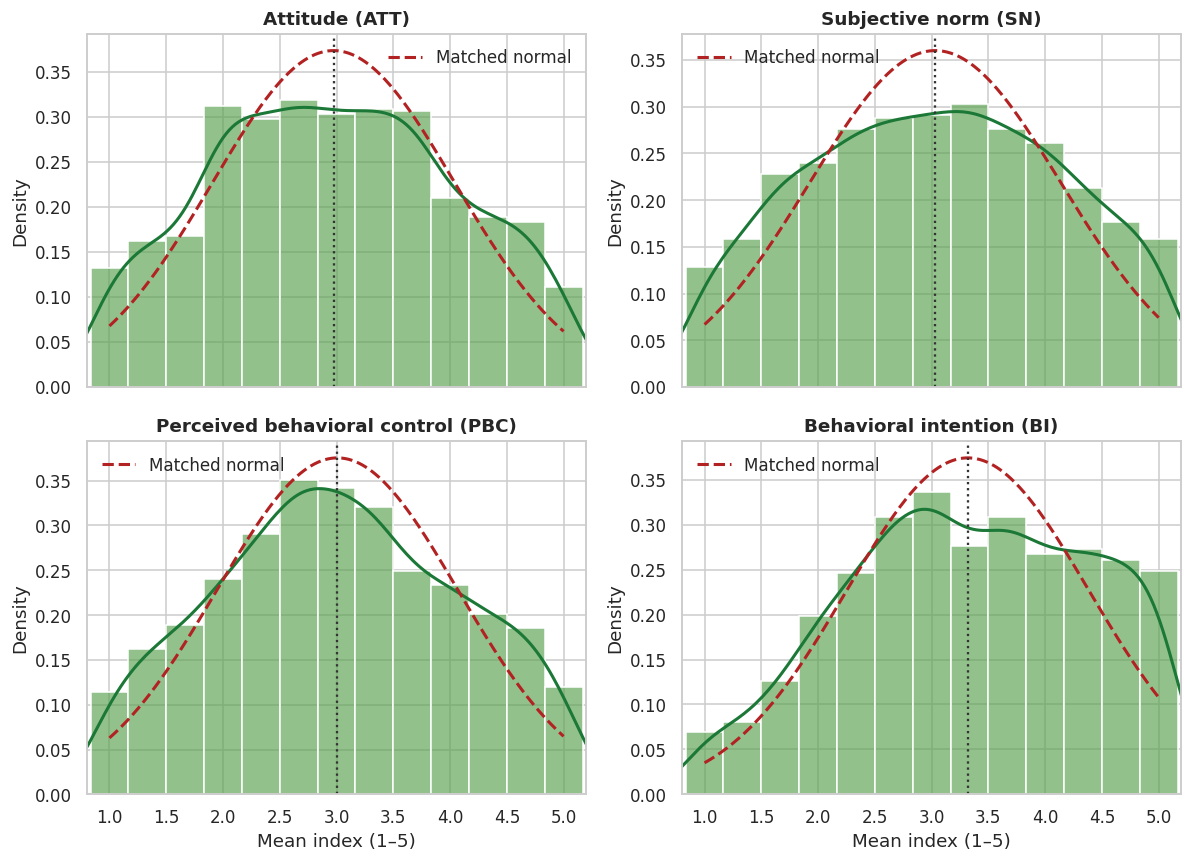

In [6]:
#| label: index-distributions
#| fig-cap: Observed TPB index distributions (bars and density curves) compared with normal densities having the same means and standard deviations (dashed lines).
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
x_grid = np.linspace(1, 5, 400)

for ax, variable in zip(axes.flat, index_columns):
    values = data[variable].dropna()
    sns.histplot(
        values,
        binwidth=1 / 3,
        binrange=(5 / 6, 31 / 6),
        stat="density",
        color="#59A14F",
        edgecolor="white",
        alpha=0.65,
        ax=ax,
    )
    sns.kdeplot(values, color="#1B7837", linewidth=2, bw_adjust=0.9, ax=ax)
    ax.plot(
        x_grid,
        stats.norm.pdf(x_grid, values.mean(), values.std(ddof=1)),
        color="#B22222",
        linestyle="--",
        linewidth=2,
        label="Matched normal",
    )
    ax.axvline(values.mean(), color="#333333", linestyle=":", linewidth=1.5)
    ax.set_title(index_labels[variable])
    ax.set_xlabel("Mean index (1–5)")
    ax.set_ylabel("Density")
    ax.set_xlim(0.8, 5.2)
    ax.legend(frameon=False)

fig.tight_layout()
plt.show()

Experimental assignment is summarized with counts and percentages. A frequency
table and bar plot are appropriate because condition is nominal rather than
continuous.

Condition,Frequency,Percent
Control,500,50.0%
Treatment,500,50.0%


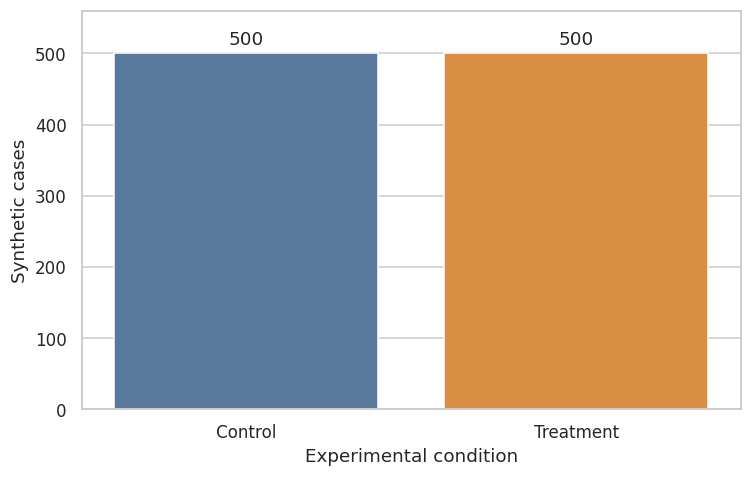

In [7]:
#| label: condition-frequency
condition_frequency = (
    data["condition"]
    .value_counts()
    .reindex(["Control", "Treatment"], fill_value=0)
    .rename_axis("Condition")
    .reset_index(name="Frequency")
)
condition_frequency["Percent"] = (
    condition_frequency["Frequency"] / len(data) * 100
)
display(
    condition_frequency.style.hide(axis="index").format(
        {"Frequency": "{:,.0f}", "Percent": "{:.1f}%"}
    )
)

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.countplot(
    data=data,
    x="condition",
    order=["Control", "Treatment"],
    hue="condition",
    palette={"Control": "#4C78A8", "Treatment": "#F28E2B"},
    legend=False,
    ax=ax,
)
for container in ax.containers:
    ax.bar_label(container, padding=3)
ax.set(xlabel="Experimental condition", ylabel="Synthetic cases")
ax.set_ylim(0, condition_frequency["Frequency"].max() * 1.12)
fig.tight_layout()
plt.show()

### 2.3.3 Bivariate analyses of DV vs. each IV

Pearson correlations test the linear bivariate associations of ATT, SN, and
PBC with BI because these are multi-item mean indices treated as continuous.
Scatter plots with fitted ordinary least-squares lines and 95% confidence bands
make direction, form, and unusual observations visible. For the binary
experimental condition, Welch's independent-samples *t* test compares mean BI
without requiring equal group variances; the mean difference and Cohen's $d$
quantify magnitude. These analyses do not substitute for the simultaneous
multivariable model in the next subsection.

In [8]:
#| label: bivariate-correlations
predictors = ["att_index", "sn_index", "pbc_index"]
correlation_rows = []

for predictor in predictors:
    complete = data[[predictor, "bi_index"]].dropna()
    result = stats.pearsonr(complete[predictor], complete["bi_index"])
    interval = result.confidence_interval(confidence_level=0.95)
    correlation_rows.append(
        {
            "Test": f"{index_labels[predictor]} vs. BI",
            "Estimate": result.statistic,
            "95% CI lower": interval.low,
            "95% CI upper": interval.high,
            "Unadjusted p": result.pvalue,
            "N": len(complete),
        }
    )

correlation_results = pd.DataFrame(correlation_rows)
correlation_results

,Test,Estimate,95% CI lower,95% CI upper,Unadjusted p,N
0,Attitude (ATT) vs. BI,0.170776,0.109947,0.230331,5.522101e-08,1000
1,Subjective norm (SN) vs. BI,0.126359,0.064874,0.186888,6.152456e-05,1000
2,Perceived behavioral control (PBC) vs. BI,0.105783,0.044079,0.166683,8.069860e-04,1000


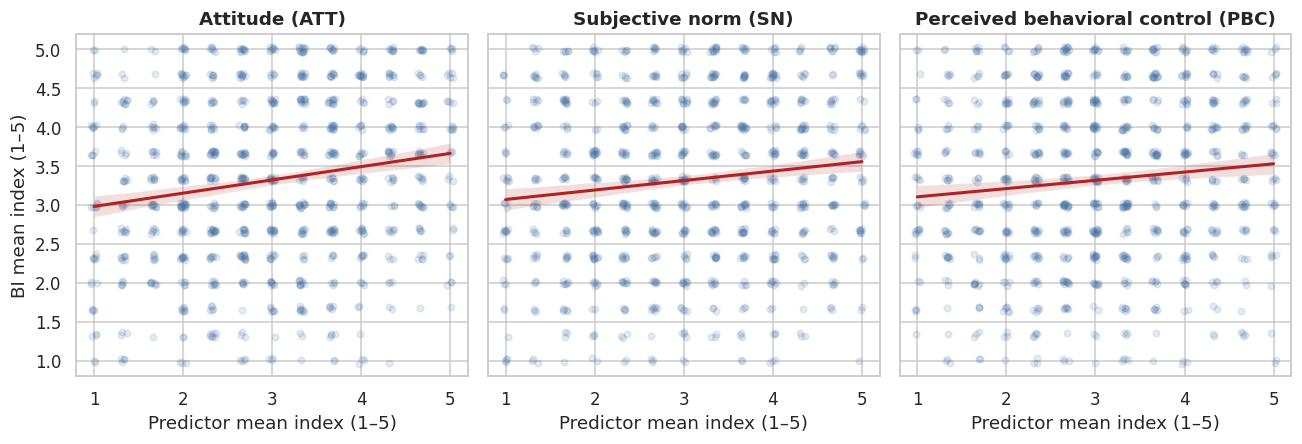

In [9]:
#| label: bivariate-scatterplots
#| fig-cap: Bivariate relationships between each TPB predictor index and behavioral intention. Lines are OLS fits with 95% confidence bands.
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), sharey=True)

for ax, predictor in zip(axes, predictors):
    sns.regplot(
        data=data,
        x=predictor,
        y="bi_index",
        x_jitter=0.035,
        y_jitter=0.035,
        scatter_kws={"alpha": 0.14, "s": 18, "color": "#4C78A8"},
        line_kws={"color": "#B22222", "linewidth": 2},
        ax=ax,
    )
    ax.set_title(index_labels[predictor])
    ax.set_xlabel("Predictor mean index (1–5)")
    ax.set_ylabel("BI mean index (1–5)" if ax is axes[0] else "")
    ax.set_xlim(0.8, 5.2)
    ax.set_ylim(0.8, 5.2)

fig.tight_layout()
plt.show()

In [10]:
#| label: condition-bivariate-test
control_bi = data.loc[data["condition"] == "Control", "bi_index"].dropna()
treatment_bi = data.loc[data["condition"] == "Treatment", "bi_index"].dropna()

welch = stats.ttest_ind(treatment_bi, control_bi, equal_var=False)
mean_difference = treatment_bi.mean() - control_bi.mean()
variance_term = (
    treatment_bi.var(ddof=1) / len(treatment_bi)
    + control_bi.var(ddof=1) / len(control_bi)
)
welch_df = variance_term**2 / (
    (treatment_bi.var(ddof=1) / len(treatment_bi)) ** 2
    / (len(treatment_bi) - 1)
    + (control_bi.var(ddof=1) / len(control_bi)) ** 2
    / (len(control_bi) - 1)
)
critical_t = stats.t.ppf(0.975, welch_df)
difference_se = np.sqrt(variance_term)
difference_ci = (
    mean_difference - critical_t * difference_se,
    mean_difference + critical_t * difference_se,
)
pooled_sd = np.sqrt(
    (
        (len(treatment_bi) - 1) * treatment_bi.var(ddof=1)
        + (len(control_bi) - 1) * control_bi.var(ddof=1)
    )
    / (len(treatment_bi) + len(control_bi) - 2)
)
cohens_d = mean_difference / pooled_sd

condition_result = pd.DataFrame(
    {
        "Test": ["Treatment vs. control BI"],
        "Estimate": [mean_difference],
        "95% CI lower": [difference_ci[0]],
        "95% CI upper": [difference_ci[1]],
        "Unadjusted p": [welch.pvalue],
        "N": [len(treatment_bi) + len(control_bi)],
    }
)

all_bivariate = pd.concat(
    [correlation_results, condition_result], ignore_index=True
)
all_bivariate["Holm-adjusted p"] = multipletests(
    all_bivariate["Unadjusted p"], method="holm"
)[1]
all_bivariate["Effect-size note"] = [
    "Pearson r",
    "Pearson r",
    "Pearson r",
    f"Mean difference; Cohen's d = {cohens_d:.3f}",
]
all_bivariate.style.hide(axis="index").format(
    {
        "Estimate": "{:.3f}",
        "95% CI lower": "{:.3f}",
        "95% CI upper": "{:.3f}",
        "Unadjusted p": "{:.4f}",
        "Holm-adjusted p": "{:.4f}",
        "N": "{:,.0f}",
    }
)

Test,Estimate,95% CI lower,95% CI upper,Unadjusted p,N,Holm-adjusted p,Effect-size note
Attitude (ATT) vs. BI,0.171,0.110,0.230,0.0000,"1,000",0.0000,Pearson r
Subjective norm (SN) vs. BI,0.126,0.065,0.187,0.0001,"1,000",0.0001,Pearson r
Perceived behavioral control (PBC) vs. BI,0.106,0.044,0.167,0.0008,"1,000",0.0008,Pearson r
Treatment vs. control BI,0.495,0.366,0.623,0.0000,"1,000",0.0000,Mean difference; Cohen's d = 0.477


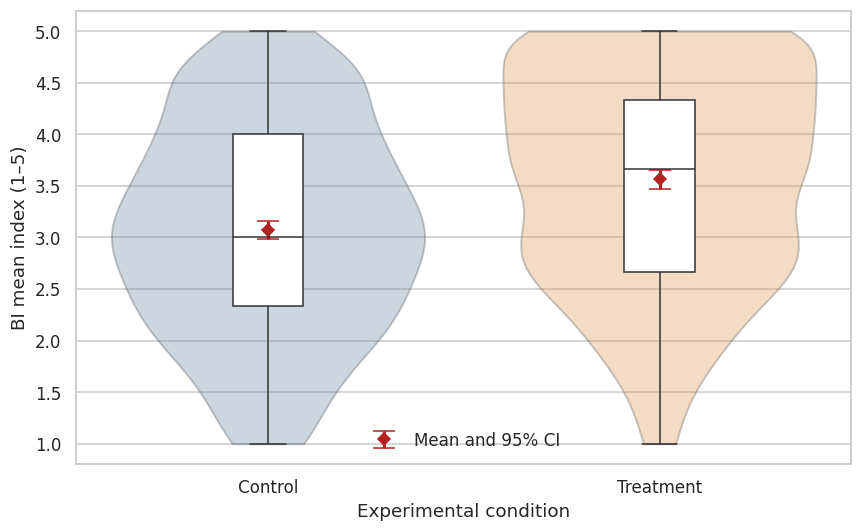

In [11]:
#| label: condition-visualization
#| fig-cap: Behavioral-intention distributions by experimental condition. Diamonds show means and error bars show 95% confidence intervals.
condition_order = ["Control", "Treatment"]
condition_palette = {"Control": "#4C78A8", "Treatment": "#F28E2B"}

fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(
    data=data,
    x="condition",
    y="bi_index",
    order=condition_order,
    hue="condition",
    palette=condition_palette,
    inner=None,
    cut=0,
    alpha=0.30,
    legend=False,
    ax=ax,
)
sns.boxplot(
    data=data,
    x="condition",
    y="bi_index",
    order=condition_order,
    width=0.18,
    showfliers=False,
    color="white",
    linecolor="#333333",
    ax=ax,
)

group_summary = (
    data.groupby("condition", observed=True)["bi_index"]
    .agg(["mean", "std", "count"])
    .reindex(condition_order)
)
group_summary["margin"] = (
    stats.t.ppf(0.975, group_summary["count"] - 1)
    * group_summary["std"]
    / np.sqrt(group_summary["count"])
)
ax.errorbar(
    [0, 1],
    group_summary["mean"],
    yerr=group_summary["margin"],
    fmt="D",
    color="#B22222",
    capsize=7,
    linewidth=2,
    label="Mean and 95% CI",
)
ax.set(xlabel="Experimental condition", ylabel="BI mean index (1–5)")
ax.set_ylim(0.8, 5.2)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

### 2.3.4 Multivariate analysis of DV vs. all IV

Hierarchical ordinary least-squares regression estimated the predictors jointly.
Model 1 entered the theoretical TPB block (ATT, SN, and PBC). Model 2 then added
experimental condition, coded 0 = control and 1 = treatment. This order tests
whether assignment explains additional variation in BI beyond the pre-treatment
TPB predictors. Model comparison uses the change in $R^2$ and the nested-model
$F$ test. Unstandardized coefficients preserve the original 1--5 metric; a
second model with standardized variables supports a visual comparison of the
relative predictor strengths.

In [12]:
#| label: hierarchical-regression
model_variables = [*predictors, "treatment", "bi_index"]
model_data = data[model_variables].dropna().copy()

x_tpb = sm.add_constant(model_data[predictors])
x_full = sm.add_constant(model_data[[*predictors, "treatment"]])
model_1 = sm.OLS(model_data["bi_index"], x_tpb).fit()
model_2 = sm.OLS(model_data["bi_index"], x_full).fit()

change_f, change_p, change_df = model_2.compare_f_test(model_1)
model_comparison = pd.DataFrame(
    {
        "Model": ["1: ATT + SN + PBC", "2: Model 1 + treatment"],
        "Predictors": [3, 4],
        "R-squared": [model_1.rsquared, model_2.rsquared],
        "Adjusted R-squared": [model_1.rsquared_adj, model_2.rsquared_adj],
        "R-squared change": [np.nan, model_2.rsquared - model_1.rsquared],
        "Change F": [np.nan, change_f],
        "df change": [np.nan, change_df],
        "Change p": [np.nan, change_p],
    }
)
model_comparison.style.hide(axis="index").format(
    {
        "R-squared": "{:.3f}",
        "Adjusted R-squared": "{:.3f}",
        "R-squared change": "{:.3f}",
        "Change F": "{:.2f}",
        "df change": "{:.0f}",
        "Change p": "{:.4f}",
    },
    na_rep="—",
)

Model,Predictors,R-squared,Adjusted R-squared,R-squared change,Change F,df change,Change p
1: ATT + SN + PBC,3,0.045,0.042,—,—,—,—
2: Model 1 + treatment,4,0.099,0.095,0.054,59.29,1,0.0000


In [13]:
#| label: full-model-coefficients
confidence_intervals = model_2.conf_int()
coefficient_table = pd.DataFrame(
    {
        "Predictor": model_2.params.index,
        "B": model_2.params.values,
        "SE": model_2.bse.values,
        "95% CI lower": confidence_intervals[0].values,
        "95% CI upper": confidence_intervals[1].values,
        "t": model_2.tvalues.values,
        "p": model_2.pvalues.values,
    }
)
coefficient_table["Predictor"] = coefficient_table["Predictor"].replace(
    {
        "const": "Intercept",
        **{name: index_labels[name] for name in predictors},
        "treatment": "Treatment (vs. control)",
    }
)
coefficient_table.style.hide(axis="index").format(
    {
        "B": "{:.3f}",
        "SE": "{:.3f}",
        "95% CI lower": "{:.3f}",
        "95% CI upper": "{:.3f}",
        "t": "{:.2f}",
        "p": "{:.4f}",
    }
)

Predictor,B,SE,95% CI lower,95% CI upper,t,p
Intercept,2.127,0.145,1.842,2.411,14.66,0.0000
Attitude (ATT),0.143,0.031,0.084,0.203,4.70,0.0000
Subjective norm (SN),0.094,0.029,0.036,0.152,3.20,0.0014
Perceived behavioral control (PBC),0.078,0.031,0.017,0.138,2.53,0.0114
Treatment (vs. control),0.494,0.064,0.368,0.619,7.70,0.0000


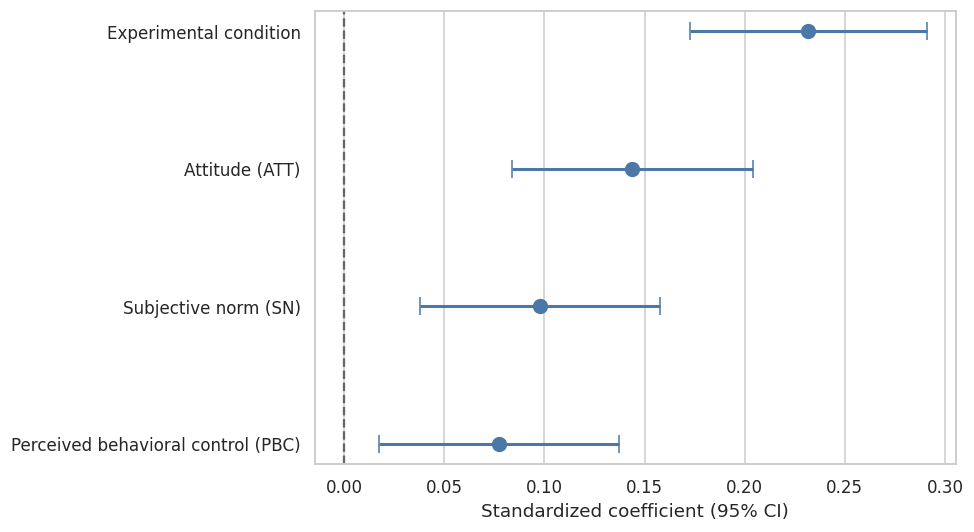

In [14]:
#| label: standardized-predictors
#| fig-cap: Relative adjusted strength of all predictors in the full model. Points are fully standardized coefficients with 95% confidence intervals.
standardized = model_data.apply(
    lambda column: (column - column.mean()) / column.std(ddof=1)
)
standardized_model = sm.OLS(
    standardized["bi_index"],
    sm.add_constant(standardized[[*predictors, "treatment"]]),
).fit()

standardized_ci = standardized_model.conf_int().drop(index="const")
standardized_coefficients = pd.DataFrame(
    {
        "Predictor": [*predictors, "treatment"],
        "Beta": standardized_model.params.drop(index="const"),
        "Lower": standardized_ci[0],
        "Upper": standardized_ci[1],
    }
).reset_index(drop=True)
standardized_coefficients["Label"] = standardized_coefficients["Predictor"].map(
    {
        **{name: index_labels[name] for name in predictors},
        "treatment": "Experimental condition",
    }
)
standardized_coefficients = standardized_coefficients.sort_values("Beta")

fig, ax = plt.subplots(figsize=(9, 5))
y_positions = np.arange(len(standardized_coefficients))
ax.axvline(0, color="#666666", linestyle="--", linewidth=1.5)
ax.errorbar(
    standardized_coefficients["Beta"],
    y_positions,
    xerr=[
        standardized_coefficients["Beta"] - standardized_coefficients["Lower"],
        standardized_coefficients["Upper"] - standardized_coefficients["Beta"],
    ],
    fmt="o",
    color="#4C78A8",
    ecolor="#4C78A8",
    markersize=9,
    capsize=6,
    linewidth=2,
)
ax.set_yticks(y_positions, standardized_coefficients["Label"])
ax.set_xlabel("Standardized coefficient (95% CI)")
ax.set_ylabel("")
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

Regression diagnostics evaluated linearity and constant error variance with a
residual-versus-fitted plot, residual normality with a Q--Q plot, influential
cases with Cook's distance, and multicollinearity with variance inflation
factors (VIFs). The Breusch--Pagan and Jarque--Bera tests, Durbin--Watson
statistic, and Cook's-distance threshold supplement rather than replace visual
inspection; at $N=1{,}000$, small departures can produce small test *p* values.

In [15]:
#| label: regression-diagnostic-statistics
residuals = model_2.resid
fitted = model_2.fittedvalues
influence = model_2.get_influence()
standardized_residuals = influence.resid_studentized_internal
cooks_distance = influence.cooks_distance[0]

bp_lm, bp_lm_p, bp_f, bp_f_p = het_breuschpagan(
    residuals, model_2.model.exog
)
jb_result = stats.jarque_bera(residuals)

diagnostic_summary = pd.DataFrame(
    {
        "Diagnostic": [
            "Breusch–Pagan LM",
            "Jarque–Bera",
            "Durbin–Watson",
            "Maximum Cook's distance",
            "Cases with Cook's D > 4/N",
        ],
        "Statistic": [
            bp_lm,
            jb_result.statistic,
            durbin_watson(residuals),
            cooks_distance.max(),
            (cooks_distance > 4 / len(model_data)).sum(),
        ],
        "p": [bp_lm_p, jb_result.pvalue, np.nan, np.nan, np.nan],
    }
)
display(
    diagnostic_summary.style.hide(axis="index").format(
        {"Statistic": "{:.4f}", "p": "{:.4f}"}, na_rep="—"
    )
)

vif_table = pd.DataFrame(
    {
        "Predictor": [*predictors, "treatment"],
        "VIF": [
            variance_inflation_factor(x_full.values, position)
            for position in range(1, x_full.shape[1])
        ],
    }
)
vif_table["Predictor"] = vif_table["Predictor"].replace(
    {
        **{name: index_labels[name] for name in predictors},
        "treatment": "Experimental condition",
    }
)
vif_table.style.hide(axis="index").format({"VIF": "{:.3f}"})

Diagnostic,Statistic,p
Breusch–Pagan LM,1.7066,0.7895
Jarque–Bera,30.1725,0.0000
Durbin–Watson,1.9669,—
Maximum Cook's distance,0.0107,—
Cases with Cook's D > 4/N,22.0000,—


Predictor,VIF
Attitude (ATT),1.036
Subjective norm (SN),1.031
Perceived behavioral control (PBC),1.028
Experimental condition,1.000


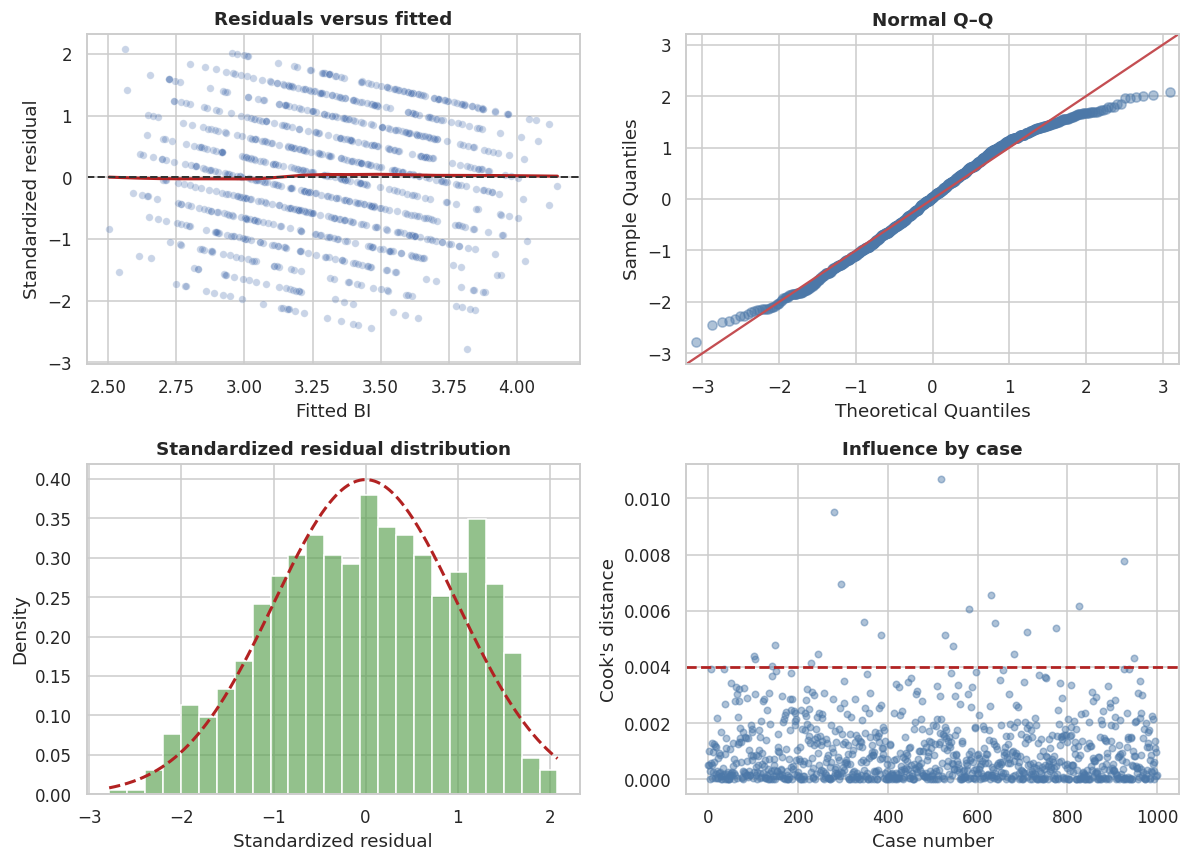

In [16]:
#| label: regression-diagnostic-plots
#| fig-cap: Diagnostic plots for the full hierarchical regression model.
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

sns.scatterplot(x=fitted, y=standardized_residuals, alpha=0.30, s=24, ax=axes[0, 0])
sns.regplot(
    x=fitted,
    y=standardized_residuals,
    scatter=False,
    lowess=True,
    color="#B22222",
    line_kws={"linewidth": 2},
    ax=axes[0, 0],
)
axes[0, 0].axhline(0, color="#333333", linestyle="--", linewidth=1.3)
axes[0, 0].set(
    title="Residuals versus fitted",
    xlabel="Fitted BI",
    ylabel="Standardized residual",
)

sm.qqplot(
    standardized_residuals,
    line="45",
    fit=True,
    markerfacecolor="#4C78A8",
    markeredgecolor="#4C78A8",
    alpha=0.45,
    ax=axes[0, 1],
)
axes[0, 1].set_title("Normal Q–Q")

sns.histplot(
    standardized_residuals,
    bins=25,
    stat="density",
    color="#59A14F",
    alpha=0.65,
    ax=axes[1, 0],
)
residual_grid = np.linspace(standardized_residuals.min(), standardized_residuals.max(), 300)
axes[1, 0].plot(
    residual_grid,
    stats.norm.pdf(residual_grid),
    color="#B22222",
    linestyle="--",
    linewidth=2,
)
axes[1, 0].set(
    title="Standardized residual distribution",
    xlabel="Standardized residual",
    ylabel="Density",
)

axes[1, 1].scatter(
    np.arange(len(cooks_distance)),
    cooks_distance,
    alpha=0.45,
    s=18,
    color="#4C78A8",
)
axes[1, 1].axhline(
    4 / len(model_data), color="#B22222", linestyle="--", linewidth=1.8
)
axes[1, 1].set(
    title="Influence by case",
    xlabel="Case number",
    ylabel="Cook's distance",
)

fig.tight_layout()
plt.show()